ISMB 2024 Tutorial: Multi-omic data integration for microbiome research using scikit-bio

# ITS presence absence
We aim to explore ITS fro, EMP biom files; for that goal; here are the ids of the biom, files; already in the shared drive

These contain ITS in the sequencing technology:
104012
104405
104910
104922
104929
133034
133098
134363
134413
134461

Goals
   - [x] Graph percentage of samples with yeast (ITS)

## Preparation

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [ ]:
from importlib.util import find_spec

In [ ]:
if find_spec('skbio') is None:
    !pip install -q scikit-bio

In [ ]:
import skbio
skbio.__version__

'0.7.0'

Import common libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

If you use Google Colab, and would like to directly mount the shared Google Drive folder containing data files, please uncomment and execute the following code.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# # Specify your remote directory
HOME = '/content/drive/MyDrive/sci-kit-bio_local/Data/emp500'

If you use Google Colab or local Jupyter, and would like to download the data file package to the current directory, please uncomment and execute the following code.

If you use local Jupyter, and have already downloaded and extracted the data file package, please specify its directory.

In [ ]:
# # Specify your local directory
#HOME = '/home/drz/Desktop/Data/emp500'

Check if the directory exists by listing its content.

In [ ]:
!ls $HOME

amplicon  assembly  masspec  README.md	sample.tsv  shotgun


## The EMP500 study

A `README.md` file within the data directory provides basic information about the study. Take a quick look at it:

In [ ]:
# Ruta al archivo
file_path = '/content/drive/MyDrive/sci-kit-bio_local/FUNGI/tables/filtered_ITS_sample_ids.txt'

# Leer líneas a una lista (removiendo saltos de línea)
with open(file_path, 'r') as f:
    sample_ITS_ids = [line.strip() for line in f if line.strip()]

# Mostrar las primeras 10 muestras
print(sample_ITS_ids[:10])
len(sample_ITS_ids)

['13114.Kshtrika1.misc.1981', '13114.Kshtrika1.misc.2063', '13114.Kshtrika1.misc.2065.P1', '13114.Kshtrika1.misc.362.P5', '13114.angenent.65.s001', '13114.angenent.65.s002', '13114.angenent.65.s005', '13114.angenent.65.s006', '13114.angenent.65.s007', '13114.berry.2.s001']


582

## Sample metadata

### Metadata table

The sample metadata table, `sample.tsv`, is a tab-separated values ([TSV](https://en.wikipedia.org/wiki/Tab-separated_values)) file with samples as rows and properties as columns. Let's take a peek at the table:

In [ ]:
!head $HOME/sample.tsv | cut -c1-100

sample_name	sample_name_original	sample_type	collection_timestamp	country	depth_sample	description	e
13114.angenent.65.s001	Angenent65.misc.104	bioreactor sludge	08/09/2011 0:00	USA - New York	not appl
13114.angenent.65.s002	Angenent65.misc.519	bioreactor sludge	9/27/12 0:00	USA - New York	not applica
13114.angenent.65.s003	Angenent65.misc.946	bioreactor sludge	11/28/13 0:00	USA - New York	not applic
13114.angenent.65.s004	Angenent65.misc.1022	bioreactor sludge	02/12/2014 0:00	USA - New York	not app
13114.angenent.65.s005	Angenent65.misc.1538	bioreactor sludge	7/13/15 0:00	USA - New York	not applic
13114.angenent.65.s006	Angenent65.misc.1622	bioreactor sludge	10/05/2015 0:00	USA - New York	not app
13114.angenent.65.s007	Angenent65.misc.1722	bioreactor sludge	1/13/15 0:00	USA - New York	not applic
13114.angenent.65.s008	Angenent65.misc.1818	bioreactor sludge	4/18/16 0:00	USA - New York	not applic
13114.angenent.65.s009	Angenent65.misc.1888	bioreactor sludge	6/27/16 0:00	USA - New York	n

In [ ]:
from skbio.metadata import SampleMetadata
meta = SampleMetadata.load(f'{HOME}/sample.tsv', default_missing_scheme='INSDC:missing')
df_meta = meta.to_dataframe()
df_meta.head(3)
#meta

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


### Creating a hierarchical map from the metadata

In [ ]:
# Crear un nuevo dataframe con valores únicos de empo_3 y sus jerarquías asociadas
df_hierarchy = (
    df_meta[['empo_1', 'empo_2', 'empo_3']]
    .drop_duplicates(subset=['empo_3'])   # evitar duplicados
    .set_index('empo_3')                  # hacer empo_3 el índice
)

print(df_hierarchy)

                                  empo_1      empo_2
empo_3                                              
Animal proximal gut      Host-associated      Animal
Sediment (non-saline)        Free-living  Non-saline
Plant surface            Host-associated       Plant
Sediment (saline)            Free-living      Saline
Soil (non-saline)            Free-living  Non-saline
Animal corpus            Host-associated      Animal
Surface (saline)             Free-living      Saline
Animal distal gut        Host-associated      Animal
Subsurface (non-saline)      Free-living  Non-saline
Water (non-saline)           Free-living  Non-saline
Water (saline)               Free-living      Saline
Plant corpus             Host-associated       Plant
Fungus corpus            Host-associated      Fungus
Animal secretion         Host-associated      Animal


## ITS sequencing

In [ ]:
from skbio import Table

In [ ]:
HOME = '/content/drive/MyDrive/sci-kit-bio_local/FUNGI'

In [ ]:
!ls $HOME

'250917_01 EMP_CreatingITSBiomFungalV3.ipynb'
 250917_02_ITS-FungalVisualization3.ipynb
'250917_03_-ShotgunGetting tsv-FungalV3.ipynb'
 250917_04_-Shotgun-FungalV3.ipynb
 250917_05_-Shotgun-YeastV3.ipynb
 250917_06_-Shotgun-Yeast_Subphylum_V3.ipynb
 250917_07_ITS-kraken-Euk-Abundance.ipynb
'250917_08_-ShotgunGetting tsv-Fungal_Food_V3.ipynb'
 bioms
 docs
 ITS_SamplesMinReads1000GenusMinPerc0.05.tsv
 ITS_SamplesMinReads1000GenusMinPerc0.0.tsv
 ITS_SamplesMinReads100GenusMinPerc0.05.tsv
 ITS_SamplesMinReads100GenusMinPerc0.0.tsv
 tables


In [ ]:
import pandas as pd

# GitHub raw file URL
github_csv_url = 'https://raw.githubusercontent.com/nselem/2025LitiVisit/main/code/absolute_abundances_with_taxonomy_isyeast.csv'
#https://github.com/nselem/2025LitiVisit/blob/main/code/kraken_absolute_isyeast.txt

# Load the CSV file into a pandas DataFrame, using the 'Unnamed: 0' column as the index
try:
    yeast_ITS_abundance_df = pd.read_csv(github_csv_url, index_col='Unnamed: 0')

    # Display the head of the DataFrame to verify
    display(yeast_ITS_abundance_df.head())

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the GitHub link is correct and the file is accessible.")

,13114.Kshtrika1.misc.1981,13114.Kshtrika1.misc.2063,13114.Kshtrika1.misc.2065.P1,13114.Kshtrika1.misc.362.P5,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.berry.2.s001,...,13114.zaneveld.9.s021,13114.zaneveld.9.s022,kingdom,phylum,class,order,family,genus,species,isyeast
SH1140570.08FU_KT198747_reps,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,Tomentella,unidentified,N
SH1140587.08FU_MG761437_reps,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,unidentified,unidentified,N
SH1141299.08FU_DQ295081_refs,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_alpinus,N
SH1141323.08FU_FJ717551_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_clandestinus,N
SH1141345.08FU_EU821696_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_vibratilis,N


In [ ]:
# Define the list of sample IDs to remove
sample_ids_to_remove = [
    '13114.Kshtrika1.misc.1981', '13114.Kshtrika1.misc.2063', '13114.Kshtrika1.misc.2065.P1',
    '13114.Kshtrika1.misc.362.P5', '13114.control.soil.grass.near.BRF', '13114.control.soil.under.pine.tree.by.Skaggs',
    '13114.control.soil.under.rock.near.century.plant', '13114.distel.72.s014', '13114.king.27.s017',
    '13114.king.27.s021', '13114.rohwer.84.s009', '13114.rohwer.84.s010', '13114.rohwer.84.s011',
    '13114.rohwer.84.s012', '13114.rohwer.84.s013', '13114.rohwer.85.s015', '13114.roy.chowdhury.45.s003',
    '13114.roy.chowdhury.45.s014', '13114.schmidt.56.s009', '13114.schmidt.56.s011', '13114.schmidt.56.s018',
    '13114.thomas.19.s001', '13114.thomas.19.s005', '13114.thomas.19.s006', '13114.thomas.19.s011',
    '13114.thomas.19.s012', '13114.thomas.19.s013', '13114.tucker.58.s002', '13114.tucker.58.s009'
]

# Remove the specified columns
yeast_ITS_abundance_df = yeast_ITS_abundance_df.drop(columns=sample_ids_to_remove, errors='ignore')

# Display the shape of the updated DataFrame to confirm removal
print(f"Shape of DataFrame after removing specified samples: {yeast_ITS_abundance_df.shape}")

# Display the head of the updated DataFrame
display(yeast_ITS_abundance_df.head())

Shape of DataFrame after removing specified samples: (543, 561)


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.berry.2.s001,13114.berry.2.s002,13114.berry.2.s003,13114.berry.2.s004,13114.berry.2.s005,...,13114.zaneveld.9.s021,13114.zaneveld.9.s022,kingdom,phylum,class,order,family,genus,species,isyeast
SH1140570.08FU_KT198747_reps,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,Tomentella,unidentified,N
SH1140587.08FU_MG761437_reps,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,unidentified,unidentified,N
SH1141299.08FU_DQ295081_refs,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_alpinus,N
SH1141323.08FU_FJ717551_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_clandestinus,N
SH1141345.08FU_EU821696_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_vibratilis,N


### Filtering samples with low read counts

Counting how many samples are below a treshold

In [ ]:
minimum_reads=1000
# Calculate the sum of abundance for each sample (column), excluding taxonomy columns
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']
abundance_columns = [col for col in yeast_ITS_abundance_df.columns if col not in taxonomy_columns]
sample_totals = yeast_ITS_abundance_df[abundance_columns].sum(axis=0)

# Count the number of samples with a total of 0 reads
num_samples_zero_reads = (sample_totals > minimum_reads).sum()

print(f"Number of samples more  than {minimum_reads} reads in total: {num_samples_zero_reads}")

Number of samples more  than 1000 reads in total: 125


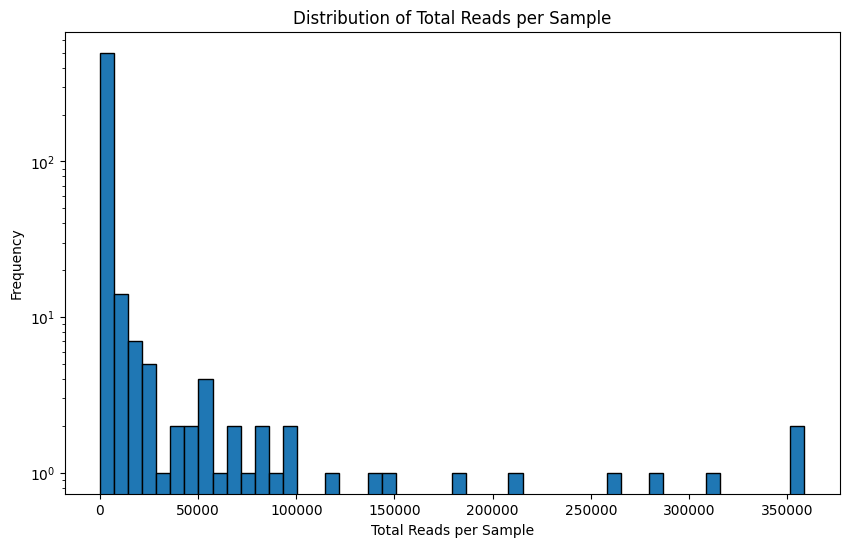

In [ ]:
import matplotlib.pyplot as plt

# Assuming sample_totals is available from the previous cell

plt.figure(figsize=(10, 6))
plt.hist(sample_totals, bins=50, edgecolor='black')
plt.xlabel("Total Reads per Sample")
plt.ylabel("Frequency")
plt.title("Distribution of Total Reads per Sample")
plt.yscale('log') # Use a log scale for the y-axis to see the distribution better
plt.show()

Considering only samples aboove a treshold =1000 reads or ate least 20 reads.

*   Elemento de la lista
*   Elemento de la lista



In [ ]:
minreads_treshold=100
# Assuming yeast_abundance_yeast_only contains the yeast abundance data with taxonomy
# Define taxonomy columns (assuming they are at the end)
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']

# Separate abundance data from taxonomy columns
abundance_columns = [col for col in yeast_ITS_abundance_df.columns if col not in taxonomy_columns]
yeast_abundance_samples = yeast_ITS_abundance_df[abundance_columns]

# Filtrar yeast_ITS_abundance_df quedandome solo son las columnas que estan en la lista sample_ITS_ids
# contar cuantas columnas son
filtered_df = yeast_ITS_abundance_df.loc[:, yeast_ITS_abundance_df.columns.isin(sample_ITS_ids)]

# Mostrar cuántas columnas quedaron
filtered_df.shape
print(f"Taxid x Samples: {filtered_df.shape}")

# (Opcional) Ver las primeras columnas
#print(filtered_df.columns[:10])


# Calculate the sum of abundance for each sample (column)
sample_totals = yeast_abundance_samples.sum(axis=0)

# Filter samples to keep only those with total abundance > 10000
samples_to_keep = sample_totals[sample_totals > minreads_treshold ].index

# Select the filtered samples from the original DataFrame
yeast_abundance_filtered_samples = filtered_df[samples_to_keep]

# Select the taxonomy columns from the original DataFrame
yeast_abundance_taxonomy = yeast_ITS_abundance_df[taxonomy_columns]

# Display the shape of the original and filtered abundance dataframes
print(f"Original ITS abundance by treshold shape (samples only): {yeast_abundance_samples.shape}")
print(f"Filtered ITS abundance  by treshold shape (samples only): {yeast_abundance_filtered_samples.shape}")

# Display the head of the filtered DataFrame with taxonomy
#display(yeast_abundance_filtered_samples.head())

# Concatenate the filtered sample columns and the taxonomy columns
# Ensure the rows are aligned by index (which they should be as they come from the same source)
yeast_abundance_filtered_with_tax = pd.concat([yeast_abundance_filtered_samples, yeast_abundance_taxonomy], axis=1)

print(f"Filtered yeast abundance shape (with taxonomy): {yeast_abundance_filtered_with_tax.shape}")
display(yeast_abundance_filtered_with_tax.head())


Taxid x Samples: (543, 553)
Original ITS abundance by treshold shape (samples only): (543, 553)
Filtered ITS abundance  by treshold shape (samples only): (543, 290)
Filtered yeast abundance shape (with taxonomy): (543, 298)


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1140570.08FU_KT198747_reps,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,Tomentella,unidentified,N
SH1140587.08FU_MG761437_reps,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,unidentified,unidentified,N
SH1141299.08FU_DQ295081_refs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_alpinus,N
SH1141323.08FU_FJ717551_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_clandestinus,N
SH1141345.08FU_EU821696_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_vibratilis,N


In [ ]:
   #'13114.Kshtrika1.misc.1981', '13114.Kshtrika1.misc.2063', '13114.Kshtrika1.misc.2065.P1',
   # '13114.Kshtrika1.misc.362.P5', '13114.control.soil.grass.near.BRF', '13114.control.soil.under.pine.tree.by.Skaggs',
   # '13114.control.soil.under.rock.near.century.plant', '13114.distel.72.s014', '13114.king.27.s017',
   # '13114.king.27.s021', '13114.rohwer.84.s009', '13114.rohwer.84.s010', '13114.rohwer.84.s011',
   # '13114.rohwer.84.s012', '13114.rohwer.84.s013', '13114.rohwer.85.s015', '13114.roy.chowdhury.45.s003',
   # '13114.roy.chowdhury.45.s014', '13114.schmidt.56.s009', '13114.schmidt.56.s011', '13114.schmidt.56.s018',
   # '13114.thomas.19.s001', '13114.thomas.19.s005', '13114.thomas.19.s006', '13114.thomas.19.s011',
   # '13114.thomas.19.s012', '13114.thomas.19.s013', '13114.tucker.58.s002', '13114.tucker.58.s009'

sample_id = "13114.rohwer.84.s012"

# 1️⃣ Check if the sample exists in the dataframe
if sample_id in yeast_abundance_filtered_with_tax.columns:
    # 2️⃣ Compute total reads for that sample
    total_reads = yeast_abundance_filtered_with_tax[sample_id].sum()
    print(f"✅ Sample '{sample_id}' is present in the dataframe.")
    print(f"Total reads in this sample: {total_reads}")
else:
    print(f"❌ Sample '{sample_id}' is NOT present in the dataframe.")

❌ Sample '13114.rohwer.84.s012' is NOT present in the dataframe.


In [ ]:
import numpy as np
import pandas as pd

sample_id_to_display = '13114.rohwer.84.s012'

# Check if the sample ID exists in the selected_columns_df
if sample_id_to_display in yeast_abundance_filtered_with_tax.columns:
    # Get the data for the specific sample
    sample_data = yeast_abundance_filtered_with_tax[sample_id_to_display]

    # Filter for non-zero values
    non_zero_values = sample_data[sample_data > 0]

    # Display all non-zero values for the specified sample ID
    print(f"Non-zero values for sample '{sample_id_to_display}':")
    display(non_zero_values)
else:
    print(f"The sample ID '{sample_id_to_display}' was not found in the selected DataFrame.")

The sample ID '13114.rohwer.84.s012' was not found in the selected DataFrame.


In [ ]:
# Get all sample IDs from the filtered table
selected_sample_ids = yeast_abundance_filtered_samples.columns.tolist()

len(selected_sample_ids)

# Define the output file path
output_file_path = f'{HOME}/tables/ITS_SamplesMinReads{minreads_treshold}filtered_sample_ids.txt'

# guardarlos en un txt
with open(output_file_path, "w") as f:
    for sid in selected_sample_ids:
        f.write(sid + "\n")

print(f"Se guardaron {len(selected_sample_ids)} sample IDs en filtered_sample_ids.txt")

Se guardaron 290 sample IDs en filtered_sample_ids.txt


### Visualizing one category to test rows with low read counts
(rows with less than a theshold would be send to cero, not present, which is ok since we are not considering relative abundance or cuantitative properties)

In [ ]:
import pandas as pd

# Umbral relativo
rowthreshold = 0.00

# 1️⃣ Calcular suma total de cada muestra (columna)
col_sums = yeast_abundance_filtered_samples.sum(axis=0)

# 2️⃣ Calcular el umbral por columna (5% del total de esa muestra)
thresholds = rowthreshold * col_sums

# 3️⃣ Aplicar el filtro: mantener valores si son mayores al umbral, sino poner 0
filtered_with_threshold = yeast_abundance_filtered_samples.copy()

for col in yeast_abundance_filtered_samples.columns:
    filtered_with_threshold[col] = yeast_abundance_filtered_samples[col].where(
        yeast_abundance_filtered_samples[col] > thresholds[col], 0
    )

# 5️⃣ (Opcional) Ver cuántos valores se conservaron
remaining_values = (filtered_with_threshold > 0).sum().sum()
print(f"\nValores retenidos (no cero): {remaining_values}")

# 4️⃣ Mostrar resultados
print("Primeras columnas después del filtrado:\n")
filtered_with_threshold.head()



Valores retenidos (no cero): 4673
Primeras columnas después del filtrado:



,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s007,13114.zaneveld.9.s008,13114.zaneveld.9.s009,13114.zaneveld.9.s013,13114.zaneveld.9.s014,13114.zaneveld.9.s015,13114.zaneveld.9.s017,13114.zaneveld.9.s018,13114.zaneveld.9.s019,13114.zaneveld.9.s020
SH1140570.08FU_KT198747_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SH1140587.08FU_MG761437_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SH1141299.08FU_DQ295081_refs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SH1141323.08FU_FJ717551_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SH1141345.08FU_EU821696_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
category='Plant corpus'
# 1Crear un diccionario sample_id → empo_3 desde el dataframe de metadatos
empo3_dict = df_meta['empo_3'].to_dict()
#empo3_dict = df_meta['env_feature'].to_dict()

# Concatenate the filtered sample columns and the taxonomy columns
# Ensure the rows are aligned by index (which they should be as they come from the same source)
filtered_with_threshold_tax = pd.concat([filtered_with_threshold, yeast_abundance_taxonomy], axis=1)

# 2Obtener las columnas (muestras) de yeast_abundance_yeast_only que son 'Animal secretion'
animal_secretion_cols = [
    col for col in filtered_with_threshold_tax.columns
    if empo3_dict.get(col) == category
]
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']

# 3Filtrar el dataframe con esas columnas
# Unir ambas listas: las columnas de muestras y las columnas de taxonomía
columns_to_keep =  animal_secretion_cols + taxonomy_columns
# Filtrar el dataframe solo con esas columnas
yeast_animal_secretion_tax = filtered_with_threshold_tax.loc[:, filtered_with_threshold_tax.columns.isin(columns_to_keep)]

#  Mostrar resultados
print(f"Total de columnas seleccionadas (Animal secretion): {len(animal_secretion_cols)}")
print("Ejemplo de columnas seleccionadas:", animal_secretion_cols[:10])
yeast_animal_secretion_tax.head()

Total de columnas seleccionadas (Animal secretion): 22
Ejemplo de columnas seleccionadas: ['13114.pinto.63.s001', '13114.pinto.63.s002', '13114.pinto.63.s003', '13114.pinto.63.s004', '13114.pinto.63.s005', '13114.pinto.63.s006', '13114.pinto.63.s007', '13114.pinto.63.s008', '13114.pinto.63.s009', '13114.pinto.63.s010']


,13114.pinto.63.s001,13114.pinto.63.s002,13114.pinto.63.s003,13114.pinto.63.s004,13114.pinto.63.s005,13114.pinto.63.s006,13114.pinto.63.s007,13114.pinto.63.s008,13114.pinto.63.s009,13114.pinto.63.s010,...,13114.pinto.63.s025,13114.pinto.63.s026,kingdom,phylum,class,order,family,genus,species,isyeast
SH1140570.08FU_KT198747_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,Tomentella,unidentified,N
SH1140587.08FU_MG761437_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Thelephorales,Thelephoraceae,unidentified,unidentified,N
SH1141299.08FU_DQ295081_refs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_alpinus,N
SH1141323.08FU_FJ717551_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_clandestinus,N
SH1141345.08FU_EU821696_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_vibratilis,N


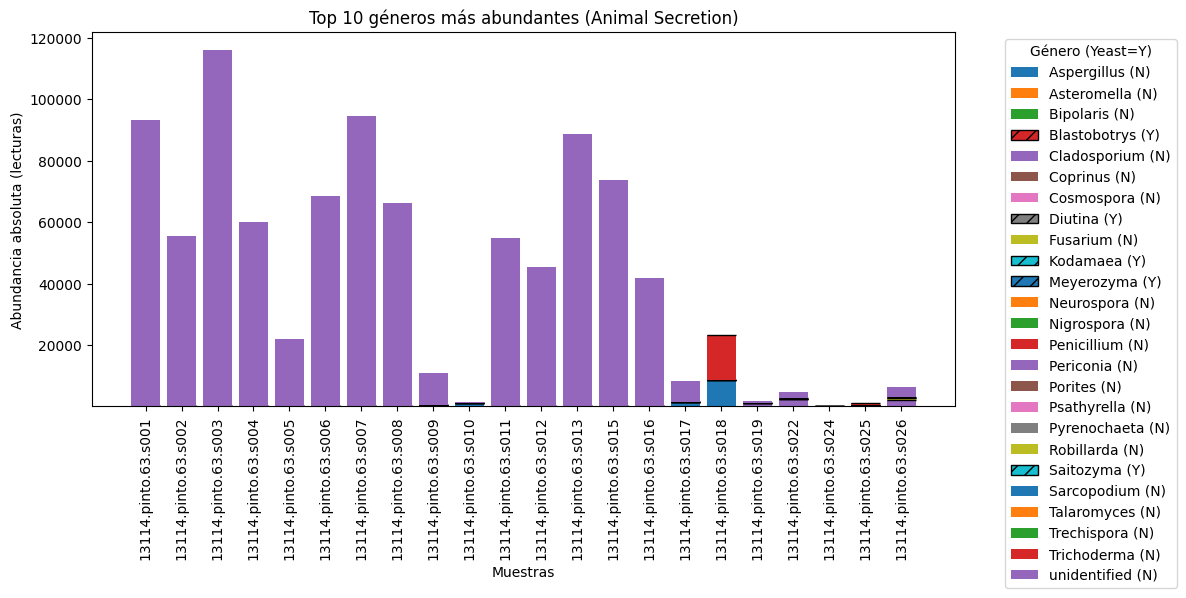

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Identificar las columnas numéricas (muestras)
sample_cols = yeast_animal_secretion_tax.select_dtypes(include='number').columns

# 2️⃣ Agrupar por género y sumar abundancias absolutas
genus_abundance = yeast_animal_secretion_tax.groupby(['genus', 'isyeast'])[sample_cols].sum().reset_index()

# 3️⃣ Calcular abundancia total y seleccionar los 10 géneros más abundantes
genus_abundance['total_abundance'] = genus_abundance[sample_cols].sum(axis=1)
top10 = (
    genus_abundance.groupby('genus')['total_abundance']
    .sum()
    .nlargest(25)
    .index
)
top10_abundance = genus_abundance[genus_abundance['genus'].isin(top10)]

# 4️⃣ Crear tabla con géneros en filas y muestras en columnas
pivot_df = top10_abundance.pivot(index='genus', columns='isyeast', values=sample_cols)
pivot_sum = top10_abundance.groupby(['genus', 'isyeast'])[sample_cols].sum()
#print(pivot_sum )
# 5️⃣ Graficar manualmente
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(sample_cols))  # base para las barras apiladas

for (genus, isyeast), row in pivot_sum.iterrows():
    values = row.values
    label = f"{genus} ({'Y' if isyeast == 'Y' else 'N'})"

    # Aplicar patrón o color según si es yeast
    if isyeast == 'Y':
        ax.bar(sample_cols, values, bottom=bottom, label=label,
               hatch='//', edgecolor='black')  # 👈 Rayas para levaduras
    else:
        ax.bar(sample_cols, values, bottom=bottom, label=label)

    bottom += values

# 6️⃣ Personalizar gráfico
ax.set_title("Top 10 géneros más abundantes (Animal Secretion)")
ax.set_xlabel("Muestras")
ax.set_ylabel("Abundancia absoluta (lecturas)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Género (Yeast=Y)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
pivot_sum

,,13114.pinto.63.s001,13114.pinto.63.s002,13114.pinto.63.s003,13114.pinto.63.s004,13114.pinto.63.s005,13114.pinto.63.s006,13114.pinto.63.s007,13114.pinto.63.s008,13114.pinto.63.s009,13114.pinto.63.s010,...,13114.pinto.63.s013,13114.pinto.63.s015,13114.pinto.63.s016,13114.pinto.63.s017,13114.pinto.63.s018,13114.pinto.63.s019,13114.pinto.63.s022,13114.pinto.63.s024,13114.pinto.63.s025,13114.pinto.63.s026
genus,isyeast,,,,,,,,,,,,,,,,,,,,,
Aspergillus,N,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1238.0,...,10.0,0.0,0.0,1479.0,8710.0,1.0,20.0,45.0,232.0,1.0
Asteromella,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
Bipolaris,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,211.0,21.0
Blastobotrys,Y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,54.0,5.0,24.0,0.0
Cladosporium,N,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,395.0,6.0,...,37.0,0.0,0.0,36.0,0.0,971.0,2230.0,5.0,2.0,2203.0
Coprinus,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
Cosmospora,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0
Diutina,Y,1.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0
Fusarium,N,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,18.0,0.0,0.0,1.0,0.0,72.0,112.0,1.0,45.0,362.0


### *Selecting* rows above a treshold

In [ ]:

# Define your threshold ratio
rowthreshold = 0.05  # (use 0.05 for 5%)
min_threshold = 20   # minimum reads threshold per sample

# 1️⃣ Compute total abundance per sample (column sums)
col_sums = yeast_abundance_filtered_samples.sum(axis=0)

# 2️⃣ Compute the dynamic threshold per column
# Each column threshold = max(5% of total reads, 20 reads)
thresholds = np.minimum(rowthreshold * col_sums, min_threshold)

print(col_sums.head())
print(thresholds.head())

# Create a binary presence/absence dataframe
presence_absence_df = (yeast_abundance_filtered_samples > thresholds).astype(int)

# Show the first few rows
presence_absence_df.head()

13114.angenent.65.s001    142.0
13114.angenent.65.s002    412.0
13114.angenent.65.s005    260.0
13114.angenent.65.s007    583.0
13114.berry.2.s008        132.0
dtype: float64
13114.angenent.65.s001     7.1
13114.angenent.65.s002    20.0
13114.angenent.65.s005    13.0
13114.angenent.65.s007    20.0
13114.berry.2.s008         6.6
dtype: float64


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s007,13114.zaneveld.9.s008,13114.zaneveld.9.s009,13114.zaneveld.9.s013,13114.zaneveld.9.s014,13114.zaneveld.9.s015,13114.zaneveld.9.s017,13114.zaneveld.9.s018,13114.zaneveld.9.s019,13114.zaneveld.9.s020
SH1140570.08FU_KT198747_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SH1140587.08FU_MG761437_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SH1141299.08FU_DQ295081_refs,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SH1141323.08FU_FJ717551_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SH1141345.08FU_EU821696_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:


# Concatenate the filtered sample columns and the taxonomy columns
# Ensure the rows are aligned by index (which they should be as they come from the same source)
yeast_presence_filtered_with_tax = pd.concat([presence_absence_df, yeast_abundance_taxonomy], axis=1)

# Identify rows in presence_absence_df that contain only zeros
non_zero_mask = presence_absence_df.sum(axis=1) > 0

# Filter yeast_presence_filtered_with_tax to keep only those rows
yeast_presence_filtered_with_tax_filtered = yeast_presence_filtered_with_tax.loc[non_zero_mask]

# Check how many rows remain
print(f"Taxa x Samples: {yeast_presence_filtered_with_tax_filtered.shape}")
print(f"Rows removed: {(~non_zero_mask).sum()}")

# Optional: summary
#print(f"Shape: {presence_absence_df.shape}")
yeast_presence_filtered_with_tax_filtered.head()


Taxa x Samples: (243, 298)
Rows removed: 300


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1141299.08FU_DQ295081_refs,0,0,0,0,0,0,0,0,0,0,...,0,0,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Cortinariaceae,Cortinarius,Cortinarius_alpinus,N
SH1142220.08FU_AY525771_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,Fungi,Ascomycota,Sordariomycetes,Sordariales,unidentified,unidentified,unidentified,N
SH1142230.08FU_KU955584_reps_singleton,0,0,0,0,0,0,0,0,0,0,...,0,0,Fungi,Ascomycota,Sordariomycetes,Sordariales,Lasiosphaeriaceae,Arnium,Arnium_arizonense,N
SH1142426.08FU_MG195513_reps,0,0,0,0,0,0,0,0,0,0,...,0,0,Fungi,Ascomycota,Leotiomycetes,Helotiales,Dermateaceae,Mollisia,unidentified,N
SH1142798.08FU_JQ693660_refs,0,0,0,0,0,0,0,0,0,0,...,0,0,Fungi,Ascomycota,Dothideomycetes,Pleosporales,Pleosporaceae,Alternaria,Alternaria_metachromatica,N


In [ ]:
# Filtrar solo las filas donde isyeast == 'Y'
yeast_rows = yeast_presence_filtered_with_tax_filtered[yeast_presence_filtered_with_tax_filtered['isyeast'] == 'Y']

# Seleccionar solo las columnas numéricas (las de abundancia/presencia)
numeric_cols = yeast_rows.select_dtypes(include='number')

# Para cada columna, verificar si hay al menos un valor positivo (> 0)
cols_with_positive = (numeric_cols > 0).any(axis=0)

# Contar cuántas columnas cumplen la condición
num_cols_with_positive = cols_with_positive.sum()

print(f"Número de columnas con al menos un valor positivo en filas isyeast='Y': {num_cols_with_positive}")


Número de columnas con al menos un valor positivo en filas isyeast='Y': 97


In [ ]:
# Assuming yeast_abundance_filtered_with_tax is available

# Count samples with assignedkingdom
Presence_samples_with_kingdom = yeast_presence_filtered_with_tax_filtered['kingdom'].dropna().shape[0]
print(f"Number of samples with assigned kingdom: {Presence_samples_with_kingdom}")

# Count samples with assigned genus
Presence_samples_with_genus = yeast_presence_filtered_with_tax_filtered['genus'].dropna().shape[0]
print(f"Number of samples with assigned genus: {Presence_samples_with_genus}")

# Count occurrences of each kingdom
Presence_kingdom_counts = yeast_presence_filtered_with_tax_filtered['kingdom'].value_counts()
print("\nCounts per kingdom:")
display(Presence_kingdom_counts)

# Count occurrences of each genus
Presence_genus_counts = yeast_presence_filtered_with_tax_filtered['genus'].value_counts()
print("\nCounts per Genus:")
display(Presence_genus_counts)

Number of samples with assigned kingdom: 243
Number of samples with assigned genus: 243

Counts per kingdom:


,count
kingdom,
Fungi,234
Metazoa,5
Protista,4



Counts per Genus:


,count
genus,
unidentified,67
Aspergillus,20
Cortinarius,7
Penicillium,7
Rhodotorula,5
...,...
Cryptococcus,1
Lepiota,1
Verticillium,1


In [ ]:
#yeast_presence_filtered_with_tax_filtered
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
Presence_yeast_abundance_yeast_only =   yeast_presence_filtered_with_tax_filtered[
      yeast_presence_filtered_with_tax_filtered['isyeast'] == 'Y'
]

# Display the shape of the filtered DataFrame
print(f"Shape of the DataFrame with yeast only taxa x samples: {Presence_yeast_abundance_yeast_only.shape}")

# Display the head of the filtered DataFrame
#display(yeast_abundance_yeast_only.head())

# Asegurar que todo sea numérico, NaN se convierten en 0
Presence_df_coerce = Presence_yeast_abundance_yeast_only.apply(pd.to_numeric, errors="coerce").fillna(0)
# Elimina todas las columnas desde 'kingdom' en adelante
Presence_df_clean = Presence_df_coerce.loc[:, : 'kingdom'].iloc[:, :-1]

# Crear nuevo dataframe con un solo renglón
Presence_new_df = pd.DataFrame([(Presence_df_clean > 0).any(axis=0).astype(int)],index=["any_gt0"])

 # 2) Group by empo_3 and sum the abundances
    # Transpose genus_relab_aligned to have samples as rows
Presence_new_df_T = Presence_new_df.T
Presence_new_df.T
# Join with metadata to group by empo_3
Presence_merged_new_df = Presence_new_df_T.join(df_meta["empo_3"])
print(Presence_merged_new_df.head())


Shape of the DataFrame with yeast only taxa x samples: (31, 298)
                        any_gt0                 empo_3
13114.angenent.65.s001        0    Animal proximal gut
13114.angenent.65.s002        0    Animal proximal gut
13114.angenent.65.s005        1    Animal proximal gut
13114.angenent.65.s007        0    Animal proximal gut
13114.berry.2.s008            1  Sediment (non-saline)


In [ ]:
Presence_merged_new_df.head(10)

,any_gt0,empo_3
13114.angenent.65.s001,0,Animal proximal gut
13114.angenent.65.s002,0,Animal proximal gut
13114.angenent.65.s005,1,Animal proximal gut
13114.angenent.65.s007,0,Animal proximal gut
13114.berry.2.s008,1,Sediment (non-saline)
13114.berry.2.s009,1,Sediment (non-saline)
13114.berry.2.s014,0,Sediment (non-saline)
13114.bittleston.68.s001,0,Plant surface
13114.bittleston.68.s002,0,Plant surface
13114.bittleston.68.s003,0,Plant surface


In [ ]:
# Exclude taxonomy columns from the filtered dataframe
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']
Presence_eu_abundance_samples = yeast_presence_filtered_with_tax_filtered.drop(columns=taxonomy_columns)

# Check if any value is greater than zero in each column (sample) for Fungi
Presence_has_Other = (Presence_eu_abundance_samples> 0).any(axis=0).astype(int)

# Filter yeast_abundance_filtered_with_tax for rows where kingdom is 'Fungi'
Presence_fungi_abundance = yeast_presence_filtered_with_tax_filtered[
    yeast_presence_filtered_with_tax_filtered['kingdom'] == 'Fungi'
]
# Exclude taxonomy columns from the filtered dataframe
Presence_fungi_abundance_samples = Presence_fungi_abundance.drop(columns=taxonomy_columns)

# Check if any value is greater than zero in each column (sample) for Fungi
Presence_has_fungi = (Presence_fungi_abundance_samples > 0).any(axis=0).astype(int)

# Add this as a new column to new_df_T
Presence_new_df_T['has_fungi'] =  (Presence_has_fungi & (~Presence_new_df_T['any_gt0'])).astype(int)

# Calculate 'Other_eukaryotes': 1 if has reads (any_gt0=1) and no fungi (has_fungi=0), else 0
Presence_new_df_T['Other_eukaryotes'] = (Presence_has_Other & (Presence_new_df_T['has_fungi'] == 0)& (~Presence_new_df_T['any_gt0'])).astype(int)

# Display the updated new_df_T
display(Presence_new_df_T.head())

,any_gt0,has_fungi,Other_eukaryotes
13114.angenent.65.s001,0,1,0
13114.angenent.65.s002,0,1,0
13114.angenent.65.s005,1,0,0
13114.angenent.65.s007,0,1,0
13114.berry.2.s008,1,0,0


In [ ]:
# Filter new_df_T to show rows where Other_eukaryotes is greater than 0
Presence_other_eukaryotes_samples = Presence_new_df_T[Presence_new_df_T['Other_eukaryotes'] > 0]

# Display the filtered DataFrame
display(Presence_other_eukaryotes_samples)

,any_gt0,has_fungi,Other_eukaryotes
13114.mousseau.88.s078,0,0,1
13114.palenik.42.s009,0,0,1
13114.palenik.42.s012,0,0,1
13114.palenik.42.s014,0,0,1
13114.palenik.42.s015,0,0,1
13114.palenik.42.s016,0,0,1
13114.palenik.42.s018,0,0,1
13114.thomas.18.s027,0,0,1
13114.thomas.18.s028,0,0,1
13114.thomas.19.s014,0,0,1


In [ ]:
# Join new_df_T with empo_3 from df_meta
Presence_merged_fungi_yeast = Presence_new_df_T.join(df_meta['empo_3'])
#merged_fungi_yeast
#
# Group by empo_3 and sum the 'any_gt0' and 'has_fungi' columns
Presence_grouped_counts = Presence_merged_fungi_yeast.groupby('empo_3')[['any_gt0', 'has_fungi','Other_eukaryotes']].sum()
#grouped_counts

# Rename columns for clarity
Presence_grouped_counts.rename(columns={'any_gt0': 'Yeast Count', 'has_fungi': 'Fungi Count'}, inplace=True)

# Add 'Total Samples' column by summing the count columns
Presence_grouped_counts['Total Samples'] = Presence_grouped_counts['Yeast Count'] + Presence_grouped_counts['Fungi Count'] + Presence_grouped_counts['Other_eukaryotes']


# Display the new DataFrame
display(Presence_grouped_counts)

,Yeast Count,Fungi Count,Other_eukaryotes,Total Samples
empo_3,,,,
Animal corpus,1,6,2,9
Animal distal gut,49,46,1,96
Animal proximal gut,1,5,0,6
Animal secretion,0,6,7,13
Fungus corpus,0,12,0,12
Plant corpus,2,20,0,22
Plant surface,3,19,4,26
Sediment (non-saline),14,5,0,19
Sediment (saline),5,18,0,23


In [ ]:
# Define the output file path
output_file_path = f'{HOME}/tables/07_ITS_SamplesMinReads{minreads_treshold}GenusMinPerc{rowthreshold}.tsv'

# Print the merged_df DataFrame to a CSV file
Presence_grouped_counts.to_csv(output_file_path,sep='\t', index=True)


## Without row (genera treshold)

In [ ]:
# Assuming yeast_abundance_filtered_with_tax is available

# Count samples with assignedkingdom
samples_with_kingdom = yeast_abundance_filtered_with_tax['kingdom'].dropna().shape[0]
print(f"Number of samples with assigned kingdom: {samples_with_kingdom}")

# Count samples with assigned genus
samples_with_genus = yeast_abundance_filtered_with_tax['genus'].dropna().shape[0]
print(f"Number of samples with assigned genus: {samples_with_genus}")

# Count occurrences of each kingdom
kingdom_counts = yeast_abundance_filtered_with_tax['kingdom'].value_counts()
print("\nCounts per kingdom:")
display(kingdom_counts)

# Count occurrences of each genus
genus_counts = yeast_abundance_filtered_with_tax['genus'].value_counts()
print("\nCounts per Genus:")
display(genus_counts)

Number of samples with assigned kingdom: 543
Number of samples with assigned genus: 543

Counts per kingdom:


,count
kingdom,
Fungi,527
Metazoa,8
Protista,5
Viridiplantae,2
Alveolata,1



Counts per Genus:


,count
genus,
unidentified,166
Aspergillus,43
Penicillium,20
Cortinarius,17
Trichoderma,8
...,...
Nectria,1
Lactuca,1
Syncephalis,1


In [ ]:
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
yeast_abundance_yeast_only =   yeast_abundance_filtered_with_tax[
      yeast_abundance_filtered_with_tax['isyeast'] == 'Y'
]

# Display the shape of the filtered DataFrame
print(f"Shape of the DataFrame with yeast only: {yeast_abundance_yeast_only.shape}")

# Display the head of the filtered DataFrame
display(yeast_abundance_yeast_only.head())

Shape of the DataFrame with yeast only: (55, 298)


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1142494.08FU_AF042432_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_indecorata,Y
SH1142496.08FU_AF042426_reps_singleton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_moriformis,Y
SH1142564.08FU_MF187249_reps_singleton,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,unidentified,Y
SH1144424.08FU_DQ104714_refs,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Pichiaceae,Pichia,Pichia_mandshurica,Y
SH1149242.08FU_FJ515208_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Cystobasidiomycetes,Erythrobasidiales,Erythrobasidiales_fam_Incertae_sedis,Hasegawazyma,Hasegawazyma_lactosa,Y


In [ ]:
# 1Crear un diccionario sample_id → empo_3 desde el dataframe de metadatos
empo3_dict = df_meta['empo_3'].to_dict()
#empo3_dict = df_meta['env_feature'].to_dict()

# 2Obtener las columnas (muestras) de yeast_abundance_yeast_only que son 'Animal secretion'
animal_secretion_cols = [
    col for col in yeast_abundance_yeast_only.columns
    if empo3_dict.get(col) == 'Animal secretion'
]

taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']

# 3Filtrar el dataframe con esas columnas
# Unir ambas listas: las columnas de muestras y las columnas de taxonomía
columns_to_keep =  animal_secretion_cols + taxonomy_columns
# Filtrar el dataframe solo con esas columnas
yeast_animal_secretion_tax = yeast_abundance_yeast_only.loc[:, yeast_abundance_yeast_only.columns.isin(columns_to_keep)]


#  Mostrar resultados
print(f"Total de columnas seleccionadas (Animal secretion): {len(animal_secretion_cols)}")
print("Ejemplo de columnas seleccionadas:", animal_secretion_cols[:10])
yeast_animal_secretion_tax.head()



Total de columnas seleccionadas (Animal secretion): 13
Ejemplo de columnas seleccionadas: ['13114.zaneveld.9.s004', '13114.zaneveld.9.s005', '13114.zaneveld.9.s006', '13114.zaneveld.9.s007', '13114.zaneveld.9.s008', '13114.zaneveld.9.s009', '13114.zaneveld.9.s013', '13114.zaneveld.9.s014', '13114.zaneveld.9.s015', '13114.zaneveld.9.s017']


,13114.zaneveld.9.s004,13114.zaneveld.9.s005,13114.zaneveld.9.s006,13114.zaneveld.9.s007,13114.zaneveld.9.s008,13114.zaneveld.9.s009,13114.zaneveld.9.s013,13114.zaneveld.9.s014,13114.zaneveld.9.s015,13114.zaneveld.9.s017,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1142494.08FU_AF042432_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_indecorata,Y
SH1142496.08FU_AF042426_reps_singleton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_moriformis,Y
SH1142564.08FU_MF187249_reps_singleton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,unidentified,Y
SH1144424.08FU_DQ104714_refs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Pichiaceae,Pichia,Pichia_mandshurica,Y
SH1149242.08FU_FJ515208_reps,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Cystobasidiomycetes,Erythrobasidiales,Erythrobasidiales_fam_Incertae_sedis,Hasegawazyma,Hasegawazyma_lactosa,Y


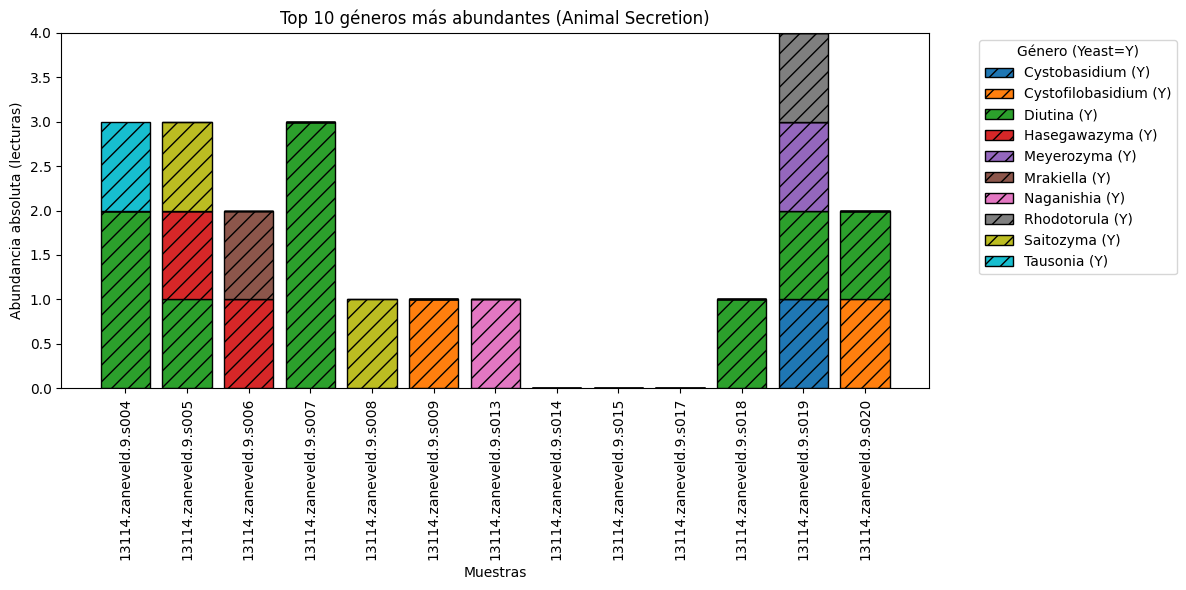

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Identificar las columnas numéricas (muestras)
sample_cols = yeast_animal_secretion_tax.select_dtypes(include='number').columns

# 2️⃣ Agrupar por género y sumar abundancias absolutas
genus_abundance = yeast_animal_secretion_tax.groupby(['genus', 'isyeast'])[sample_cols].sum().reset_index()

# 3️⃣ Calcular abundancia total y seleccionar los 10 géneros más abundantes
genus_abundance['total_abundance'] = genus_abundance[sample_cols].sum(axis=1)
top10 = (
    genus_abundance.groupby('genus')['total_abundance']
    .sum()
    .nlargest(10)
    .index
)
top10_abundance = genus_abundance[genus_abundance['genus'].isin(top10)]

# 4️⃣ Crear tabla con géneros en filas y muestras en columnas
pivot_df = top10_abundance.pivot(index='genus', columns='isyeast', values=sample_cols)
pivot_sum = top10_abundance.groupby(['genus', 'isyeast'])[sample_cols].sum()

# 5️⃣ Graficar manualmente
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(sample_cols))  # base para las barras apiladas

for (genus, isyeast), row in pivot_sum.iterrows():
    values = row.values
    label = f"{genus} ({'Y' if isyeast == 'Y' else 'N'})"

    # Aplicar patrón o color según si es yeast
    if isyeast == 'Y':
        ax.bar(sample_cols, values, bottom=bottom, label=label,
               hatch='//', edgecolor='black')  # 👈 Rayas para levaduras
    else:
        ax.bar(sample_cols, values, bottom=bottom, label=label)

    bottom += values

# 6️⃣ Personalizar gráfico
ax.set_title("Top 10 géneros más abundantes (Animal Secretion)")
ax.set_xlabel("Muestras")
ax.set_ylabel("Abundancia absoluta (lecturas)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Género (Yeast=Y)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Asegurar que todo sea numérico, NaN se convierten en 0
df_coerce = yeast_abundance_yeast_only.apply(pd.to_numeric, errors="coerce").fillna(0)
# Elimina todas las columnas desde 'kingdom' en adelante
df_clean = df_coerce.loc[:, : 'kingdom'].iloc[:, :-1]

# Crear nuevo dataframe con un solo renglón
new_df = pd.DataFrame([(df_clean > 0).any(axis=0).astype(int)],index=["any_gt0"])

 # 2) Group by empo_3 and sum the abundances
    # Transpose genus_relab_aligned to have samples as rows
new_df_T = new_df.T
new_df.T
# Join with metadata to group by empo_3
merged_new_df = new_df_T.join(df_meta["empo_3"])
print(merged_new_df.head())


                        any_gt0                 empo_3
13114.angenent.65.s001        1    Animal proximal gut
13114.angenent.65.s002        1    Animal proximal gut
13114.angenent.65.s005        1    Animal proximal gut
13114.angenent.65.s007        1    Animal proximal gut
13114.berry.2.s008            1  Sediment (non-saline)


In [ ]:
# Exclude taxonomy columns from the filtered dataframe
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']
eu_abundance_samples = yeast_abundance_filtered_with_tax.drop(columns=taxonomy_columns)

# Check if any value is greater than zero in each column (sample) for Fungi
has_Other = (eu_abundance_samples> 0).any(axis=0).astype(int)

# Filter yeast_abundance_filtered_with_tax for rows where kingdom is 'Fungi'
fungi_abundance = yeast_abundance_filtered_with_tax[
    yeast_abundance_filtered_with_tax['kingdom'] == 'Fungi'
]
# Exclude taxonomy columns from the filtered dataframe
fungi_abundance_samples = fungi_abundance.drop(columns=taxonomy_columns)

# Check if any value is greater than zero in each column (sample) for Fungi
has_fungi = (fungi_abundance_samples > 0).any(axis=0).astype(int)

# Add this as a new column to new_df_T
new_df_T['has_fungi'] =  (has_fungi & (~new_df_T['any_gt0'])).astype(int)

# Calculate 'Other_eukaryotes': 1 if has reads (any_gt0=1) and no fungi (has_fungi=0), else 0
new_df_T['Other_eukaryotes'] = (has_Other & (new_df_T['has_fungi'] == 0)& (~new_df_T['any_gt0'])).astype(int)

# Display the updated new_df_T
display(new_df_T.head())

,any_gt0,has_fungi,Other_eukaryotes
13114.angenent.65.s001,1,0,0
13114.angenent.65.s002,1,0,0
13114.angenent.65.s005,1,0,0
13114.angenent.65.s007,1,0,0
13114.berry.2.s008,1,0,0


In [ ]:
# Filter new_df_T to show rows where Other_eukaryotes is greater than 0
other_eukaryotes_samples = new_df_T[new_df_T['Other_eukaryotes'] > 0]

# Display the filtered DataFrame
display(other_eukaryotes_samples)

,any_gt0,has_fungi,Other_eukaryotes
13114.palenik.42.s016,0,0,1


In [ ]:
# Select the column for the specified sample
sample_data = yeast_ITS_abundance_df['13114.palenik.42.s016']

# Filter for rows where abundance is greater than 0 and the kingdom is not NaN
kingdoms_in_sample = yeast_ITS_abundance_df.loc[sample_data > 0, 'kingdom'].dropna()

# Get the unique kingdoms
unique_kingdoms = kingdoms_in_sample.unique()

print(f"Kingdoms present in sample 13114.palenik.42.s016: {unique_kingdoms}")

Kingdoms present in sample 13114.palenik.42.s016: ['Metazoa' 'Protista' 'Alveolata']


In [ ]:
# Join new_df_T with empo_3 from df_meta
merged_fungi_yeast = new_df_T.join(df_meta['empo_3'])
#merged_fungi_yeast
#
# Group by empo_3 and sum the 'any_gt0' and 'has_fungi' columns
grouped_counts = merged_fungi_yeast.groupby('empo_3')[['any_gt0', 'has_fungi','Other_eukaryotes']].sum()
#grouped_counts

# Rename columns for clarity
grouped_counts.rename(columns={'any_gt0': 'Yeast Count', 'has_fungi': 'Fungi Count'}, inplace=True)

# Add 'Total Samples' column by summing the count columns
grouped_counts['Total Samples'] = grouped_counts['Yeast Count'] + grouped_counts['Fungi Count'] + grouped_counts['Other_eukaryotes']


# Display the new DataFrame
display(grouped_counts)

,Yeast Count,Fungi Count,Other_eukaryotes,Total Samples
empo_3,,,,
Animal corpus,7,2,0,9
Animal distal gut,69,27,0,96
Animal proximal gut,4,2,0,6
Animal secretion,10,3,0,13
Fungus corpus,10,2,0,12
Plant corpus,17,5,0,22
Plant surface,11,15,0,26
Sediment (non-saline),19,0,0,19
Sediment (saline),19,4,0,23


In [ ]:
# Define the output file path
output_file_path = f'{HOME}/tables/07_ITS_1000reads_grouped_counts.tsv'

# Print the merged_df DataFrame to a CSV file
grouped_counts.to_csv(output_file_path,sep='\t', index=True)



In [ ]:
# Calculate the sum of the 'Total Samples' column
total_samples_sum = grouped_counts['Total Samples'].sum()

print(f"Total number of samples across all EMPO 3 categories: {total_samples_sum}")

Total number of samples across all EMPO 3 categories: 290


In [ ]:
# Calculate percentages for each category
grouped_percentages = grouped_counts[['Yeast Count', 'Fungi Count', 'Other_eukaryotes']].div(grouped_counts['Total Samples'], axis=0) * 100

# Display the new DataFrame with percentages
display(grouped_percentages)

,Yeast Count,Fungi Count,Other_eukaryotes
empo_3,,,
Animal corpus,77.777778,22.222222,0.000000
Animal distal gut,71.875000,28.125000,0.000000
Animal proximal gut,66.666667,33.333333,0.000000
Animal secretion,76.923077,23.076923,0.000000
Fungus corpus,83.333333,16.666667,0.000000
Plant corpus,77.272727,22.727273,0.000000
Plant surface,42.307692,57.692308,0.000000
Sediment (non-saline),100.000000,0.000000,0.000000
Sediment (saline),82.608696,17.391304,0.000000


In [ ]:
# Convert the percentages Series to a DataFrame for merging
percentages_df = grouped_percentages.reset_index()
percentages_df.rename(columns={'index': 'empo_3'}, inplace=True)

# Merge with df_hierarchy to get EMPO 1 and EMPO 2 for sorting
merged_percentages = pd.merge(percentages_df, df_hierarchy[['empo_1', 'empo_2']], on='empo_3', how='left')

# Sort by EMPO 1 and EMPO 2
sorted_percentages_df = merged_percentages.sort_values(by=['empo_1', 'empo_2'])

# Drop 'empo_1' and 'empo_2' columns
sorted_percentages_df = sorted_percentages_df.drop(columns=['empo_1', 'empo_2'])

# Set empo_3 back as the index
sorted_percentages = sorted_percentages_df.set_index('empo_3')
#'Fungi Count', 'Other_eukaryotes'
sorted_percentages
# Display the sorted percentages
#display(sorted_percentages)

,Yeast Count,Fungi Count,Other_eukaryotes
empo_3,,,
Sediment (non-saline),100.000000,0.000000,0.000000
Soil (non-saline),81.395349,18.604651,0.000000
Water (non-saline),100.000000,0.000000,0.000000
Sediment (saline),82.608696,17.391304,0.000000
Water (saline),64.705882,29.411765,5.882353
Animal corpus,77.777778,22.222222,0.000000
Animal distal gut,71.875000,28.125000,0.000000
Animal proximal gut,66.666667,33.333333,0.000000
Animal secretion,76.923077,23.076923,0.000000


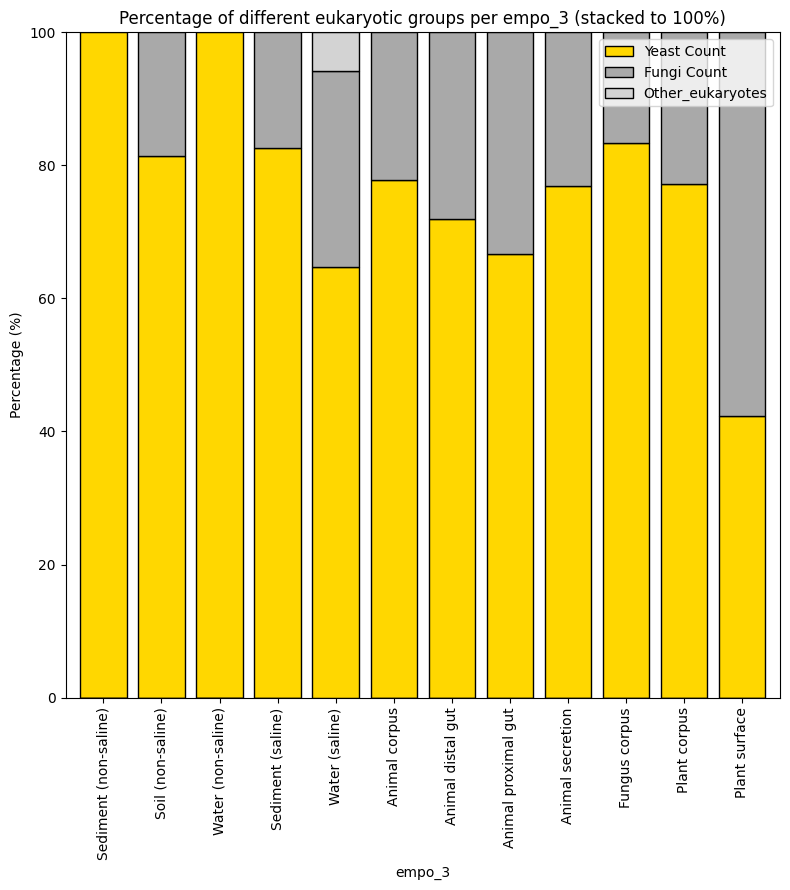

In [ ]:
# Plot stacked bar using sorted_percentages
ax = sorted_percentages.plot(
    kind="bar",
    stacked=True,
    color=["gold", "darkgray", "lightgray"],
    edgecolor="black",
    width=0.8, # Reduced width for less space between bars
    figsize=(8,9)
)

plt.ylabel("Percentage (%)")
plt.title("Percentage of different eukaryotic groups per empo_3 (stacked to 100%)")

# Add the number of samples to the x-axis labels
# Assuming empo_counts DataFrame is available from a previous cell
if 'empo_counts' in locals() and isinstance(grouped_counts, pd.DataFrame):
    new_labels = [f"{label}\n(n={grouped_counts.loc[label, 'Total Samples']})" for label in sorted_percentages.index]
    ax.set_xticklabels(new_labels, rotation=90, ha="center") # Rotated labels vertically
else:
    plt.xticks(rotation=90, ha="center") # Rotated labels vertically


plt.ylim(0, 100)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
  yeast_abundance_df=yeast_abundance_yeast_only
  yeast_abundance_df

,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1142494.08FU_AF042432_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_indecorata,Y
SH1142496.08FU_AF042426_reps_singleton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_moriformis,Y
SH1142564.08FU_MF187249_reps_singleton,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,unidentified,Y
SH1144424.08FU_DQ104714_refs,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Pichiaceae,Pichia,Pichia_mandshurica,Y
SH1149242.08FU_FJ515208_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Cystobasidiomycetes,Erythrobasidiales,Erythrobasidiales_fam_Incertae_sedis,Hasegawazyma,Hasegawazyma_lactosa,Y
SH1150802.08FU_EU343861_refs,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Debaryomycetaceae,Schwanniomyces,Schwanniomyces_yamadae,Y
SH1150824.08FU_KF582611_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Debaryomycetaceae,Kurtzmaniella,unidentified,Y
SH1156064.08FU_JF970193_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Metschnikowiaceae,Kodamaea,Kodamaea_ohmeri,Y
SH1156065.08FU_KU962020_reps_singleton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Metschnikowiaceae,Kodamaea,Kodamaea_ohmeri,Y
SH1158813.08FU_EF203929_reps_singleton,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Pichiaceae,Pichia,Pichia_kluyveri,Y


In [ ]:
# Define taxonomy columns (assuming they are at the end)
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']

# Separate abundance data from taxonomy columns
abundance_columns = [col for col in yeast_abundance_df.columns if col not in taxonomy_columns]
yeast_abundance_samples = yeast_abundance_df[abundance_columns]

# Find the intersection of sample IDs in yeast_abundance_samples and df_meta index
common_sample_ids = yeast_abundance_samples.columns.intersection(df_meta.index)

# Select the common sample columns from the original DataFrame
yeast_abundance_filtered_samples = yeast_abundance_df[common_sample_ids]

# Select the taxonomy columns from the original DataFrame
yeast_abundance_taxonomy = yeast_abundance_df[taxonomy_columns]

# Concatenate the filtered sample columns and the taxonomy columns
# Ensure the rows are aligned by index (which they should be as they come from the same source)
yeast_abundance_filtered_with_tax = pd.concat([yeast_abundance_filtered_samples, yeast_abundance_taxonomy], axis=1)


# Display the shape of the original and filtered abundance dataframes
print(f"Original yeast abundance shape (samples only): {yeast_abundance_samples.shape}")
print(f"Filtered yeast abundance shape (samples only): {yeast_abundance_filtered_samples.shape}")
print(f"Filtered yeast abundance shape (with taxonomy): {yeast_abundance_filtered_with_tax.shape}")


# Display the head of the filtered DataFrame with taxonomy
display(yeast_abundance_filtered_with_tax.head())

Original yeast abundance shape (samples only): (55, 290)
Filtered yeast abundance shape (samples only): (55, 290)
Filtered yeast abundance shape (with taxonomy): (55, 298)


,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s005,13114.angenent.65.s007,13114.berry.2.s008,13114.berry.2.s009,13114.berry.2.s014,13114.bittleston.68.s001,13114.bittleston.68.s002,13114.bittleston.68.s003,...,13114.zaneveld.9.s019,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,isyeast
SH1142494.08FU_AF042432_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_indecorata,Y
SH1142496.08FU_AF042426_reps_singleton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Tremellaceae,Tremella,Tremella_moriformis,Y
SH1142564.08FU_MF187249_reps_singleton,NaN,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Nakaseomyces,unidentified,Y
SH1144424.08FU_DQ104714_refs,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Ascomycota,Saccharomycetes,Saccharomycetales,Pichiaceae,Pichia,Pichia_mandshurica,Y
SH1149242.08FU_FJ515208_reps,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Fungi,Basidiomycota,Cystobasidiomycetes,Erythrobasidiales,Erythrobasidiales_fam_Incertae_sedis,Hasegawazyma,Hasegawazyma_lactosa,Y


### Taxonomy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# collapse OTU/ASV table to a chosen taxonomic rank
def collapse_by_rank(abund_df, tax_df, rank="genus", relative=False, fill_label="Unassigned"):
    labels = tax_df[rank].replace("", fill_label) if rank in tax_df.columns else pd.Series(fill_label, index=tax_df.index)
    collapsed = abund_df.groupby(labels).sum()
    if relative:
        collapsed = collapsed.div(collapsed.sum(axis=0), axis=1).fillna(0)
    # order by total abundance
    collapsed["__total__"] = collapsed.sum(axis=1)
    collapsed = collapsed.sort_values("__total__", ascending=False).drop(columns="__total__")
    return collapsed

def align_to_meta(genus_rel, meta_df, empo_col="empo_3", sample_col=None):
    # ensure meta_df index is sample IDs that match genus_rel columns
    if sample_col and sample_col in meta_df.columns:
        meta_df = meta_df.set_index(sample_col)
    # intersect samples
    common = genus_rel.columns.intersection(meta_df.index)
    genus_rel = genus_rel.loc[:, common]
    meta_sub = meta_df.loc[common]
    # keep only rows with EMPO info
    if empo_col not in meta_sub.columns:
        raise ValueError(f"Column '{empo_col}' not found in metadata.")
    meta_sub[empo_col] = meta_sub[empo_col].fillna("EMPO_missing").replace("", "EMPO_missing")
    return genus_rel, meta_sub

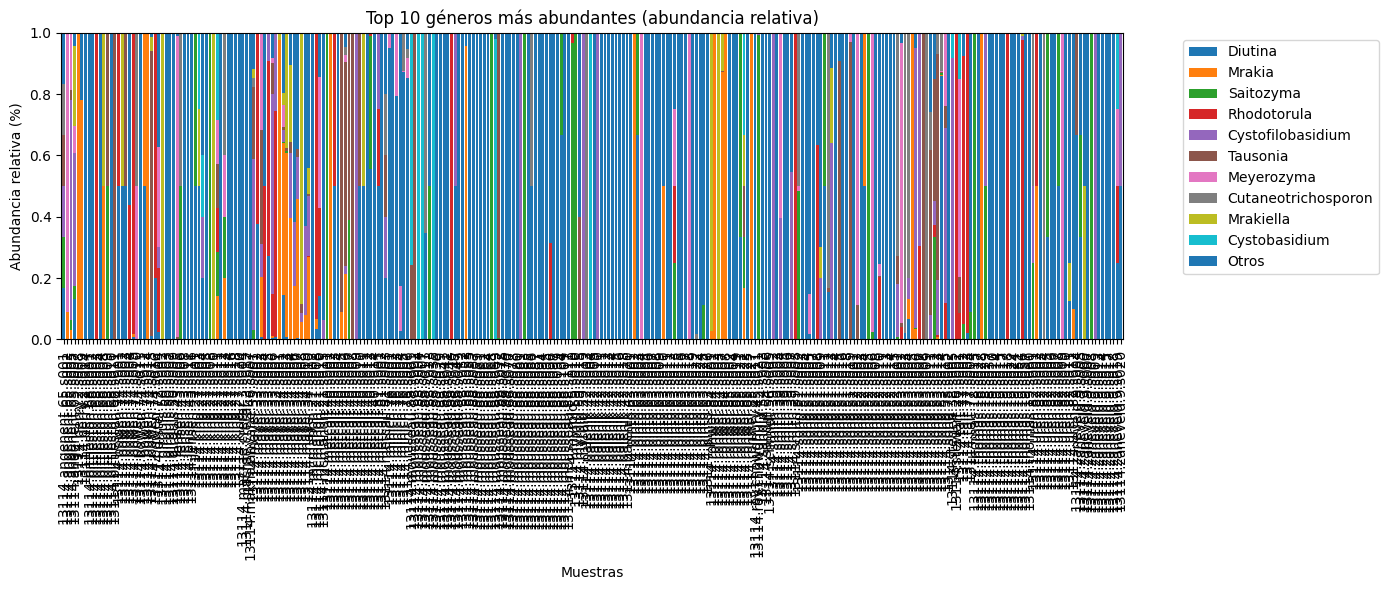

In [ ]:
import matplotlib.pyplot as plt

# Assuming yeast_abundance_filtered_with_tax contains the filtered abundance data with taxonomy
# Separate abundance and taxonomy data
taxonomy_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'isyeast']
abund = yeast_abundance_filtered_with_tax.drop(columns=taxonomy_columns)
tax_df = yeast_abundance_filtered_with_tax[taxonomy_columns]


# 1) Collapse by genus and calculate relative abundance (% per sample)
# Ensure 'genus' column exists and handle potential NaNs
if 'genus' in tax_df.columns:
    genus_relab = collapse_by_rank(abund, tax_df, rank="genus", relative=True)

    # 2) Select the 10 most abundant genera overall
    top10 = genus_relab.sum(axis=1).sort_values(ascending=False).head(10).index

    # 3) Group: top 10 + "Others"
    genus_relab_top = genus_relab.loc[top10].copy()
    otros = 1 - genus_relab_top.sum(axis=0)
    genus_relab_top.loc["Otros"] = otros.clip(lower=0) # Ensure 'Otros' is non-negative

    # 4) Transpose for plotting (samples in X, genera in colors)
    df_plot = genus_relab_top.T  # rows = samples, columns = genera

    # 5) Make stacked bar plot
    ax = df_plot.plot(kind="bar", stacked=True, figsize=(14,6), width=0.8)

    plt.ylabel("Abundancia relativa (%)")
    plt.xlabel("Muestras")
    plt.title("Top 10 géneros más abundantes (abundancia relativa)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Genus column not found in the taxonomy data.")

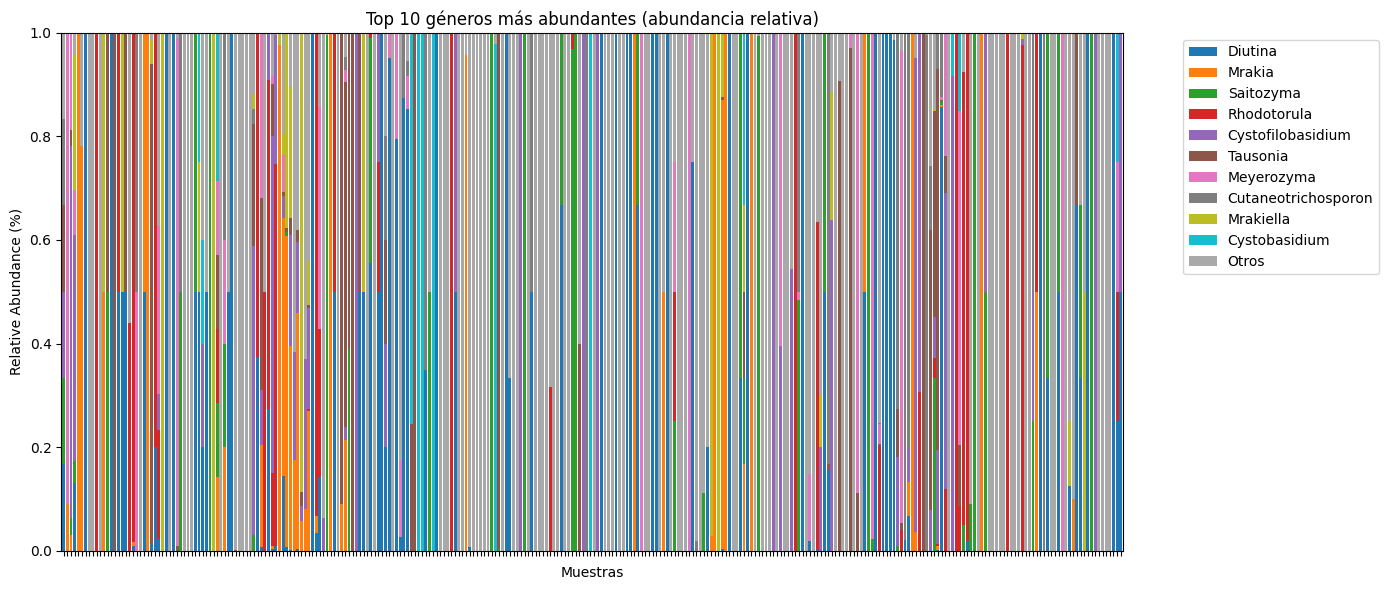

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assuming genus_relab (relative abundance by genus) is available

# 1) Select the 10 most abundant genera overall
top10 = genus_relab.sum(axis=1).sort_values(ascending=False).head(10).index

# 2) Group: top 10 + "Otros"
genus_relab_top = genus_relab.loc[top10].copy()
otros = 1 - genus_relab_top.sum(axis=0)
genus_relab_top.loc["Otros"] = otros.clip(lower=0) # Ensure 'Otros' is non-negative

# 3) Transpose for plotting (samples in X, genera in colors)
df_plot = genus_relab_top.T  # rows = samples, columns = géneros

# 4) Define colors: use default color cycle for most, light gray for 'unidentified', dark gray for 'Otros'
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {}
color_index = 0
for col in df_plot.columns:
    if col == 'unidentified':
        color_map[col] = 'lightgray'
    elif col == 'Otros': # Add condition for 'Otros'
        color_map[col] = 'darkgray'
    else:
        color_map[col] = default_colors[color_index % len(default_colors)]
        color_index += 1


# 5) Make stacked bar plot
ax = df_plot.plot(kind="bar", stacked=True, figsize=(14,6), width=0.8, color=[color_map[col] for col in df_plot.columns])

# Remove x-axis tick labels
ax.set_xticklabels([])

plt.ylabel("Relative Abundance (%)")
plt.xlabel("Muestras")
plt.title("Top 10 géneros más abundantes (abundancia relativa)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualization of stack bars by empo3

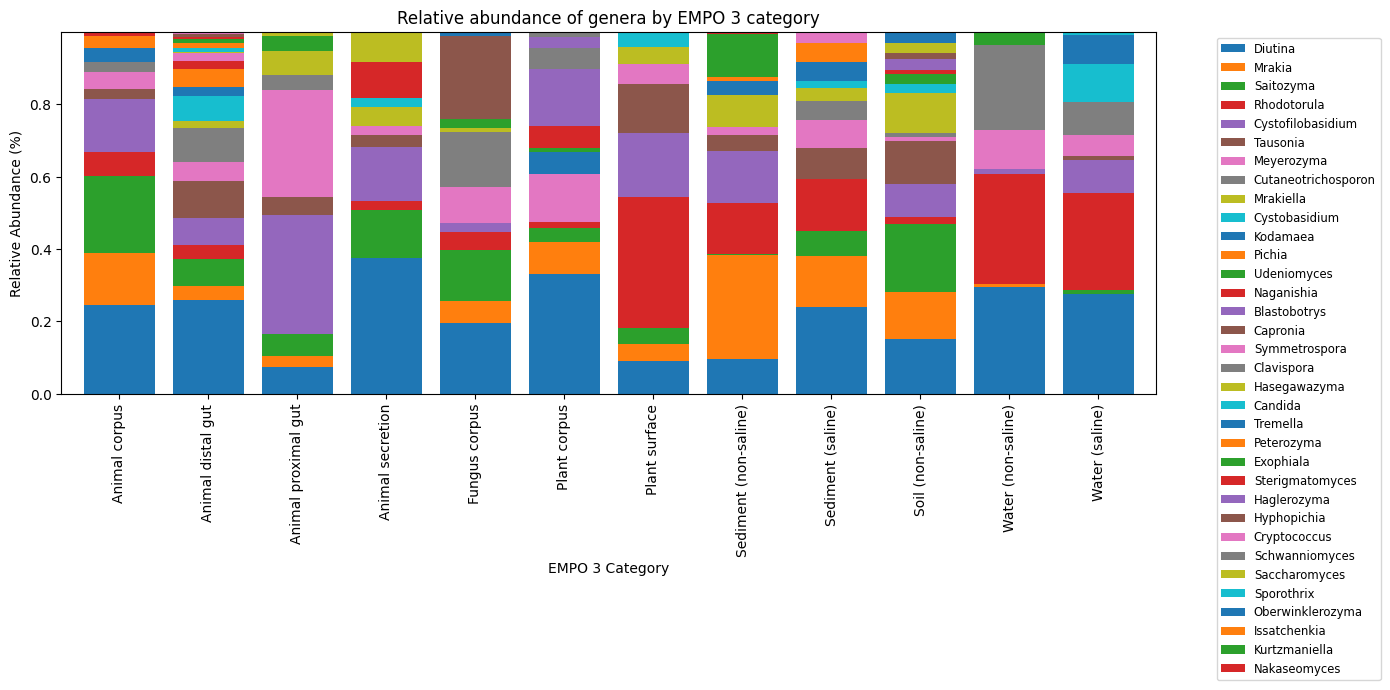

In [ ]:
import matplotlib.pyplot as plt

# Assuming genus_relab (relative abundance by genus) and df_meta are available

# 1) Align abundance data to metadata and filter for samples with empo_3 information
try:
    genus_relab_aligned, meta_aligned = align_to_meta(genus_relab, df_meta, empo_col="empo_3")

    # 2) Group by empo_3 and sum the abundances
    # Transpose genus_relab_aligned to have samples as rows
    genus_relab_aligned_T = genus_relab_aligned.T

    # Join with metadata to group by empo_3
    merged_df = genus_relab_aligned_T.join(meta_aligned["empo_3"])

    # Group by empo_3 and sum the abundances for each genus
    grouped_abundance = merged_df.groupby("empo_3").sum()

    # 3) Calculate relative abundance within each empo_3 group
    grouped_relab = grouped_abundance.div(grouped_abundance.sum(axis=1), axis=0).fillna(0)

    # 4) Transpose for plotting (empo_3 in X, genera in colors)
    df_plot_empo = grouped_relab # empo_3 are already in index, will be x-axis

    # 5) Make stacked bar plot
    ax = df_plot_empo.plot(kind="bar", stacked=True, figsize=(14,6), width=0.8)

    plt.ylabel("Relative Abundance (%)")
    plt.xlabel("EMPO 3 Category")
    plt.title("Relative abundance of genera by EMPO 3 category")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error aligning data: {e}")
    print("Please ensure the 'empo_3' column exists in your metadata and the sample IDs match.")
except Exception as e:
    print(f"An error occurred during plotting: {e}")

Visualization of the top 5 abundant genera by empo in boxplots
```
# Esto tiene formato de código
```

